In [107]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
import math
import sklearn
%matplotlib inline

titanic_data = pd.read_csv('Titanic.csv')
titanic_data.shape

(418, 12)

In [108]:
titanic_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [109]:
print("number of passengers in original data: " + str(len(titanic_data.index)))

number of passengers in original data: 418


<Axes: xlabel='Survived', ylabel='count'>

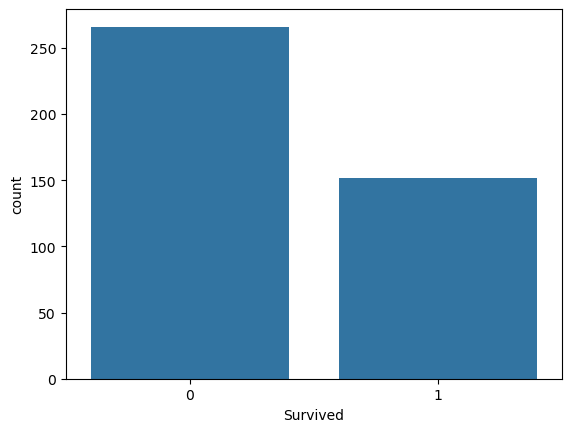

In [110]:
# analysing data
sns.countplot(x='Survived' , data=titanic_data)

<Axes: xlabel='Survived', ylabel='count'>

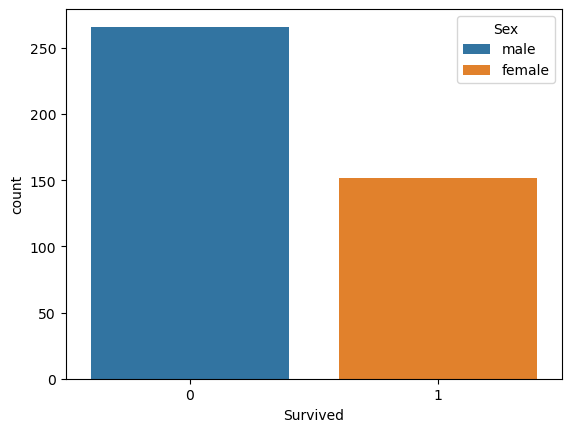

In [111]:
sns.countplot(x="Survived" , hue="Sex" ,  data=titanic_data)

<Axes: xlabel='Survived', ylabel='count'>

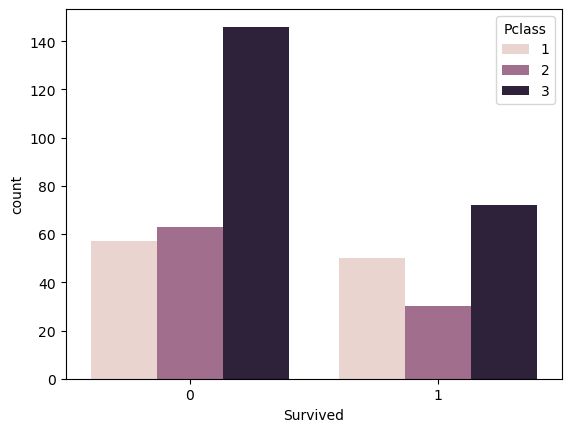

In [112]:

sns.countplot(x="Survived" , hue="Pclass" ,  data=titanic_data)

<Axes: ylabel='Frequency'>

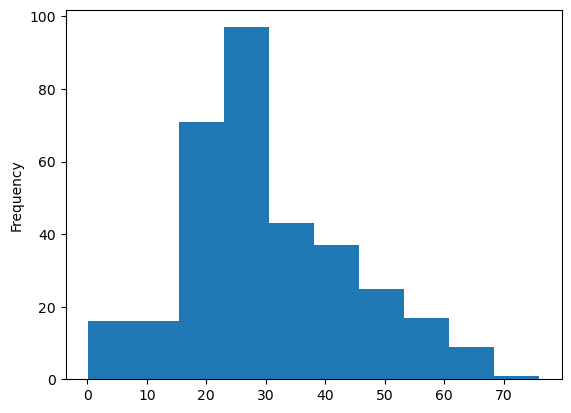

In [113]:
titanic_data["Age"].plot.hist()

<Axes: ylabel='Frequency'>

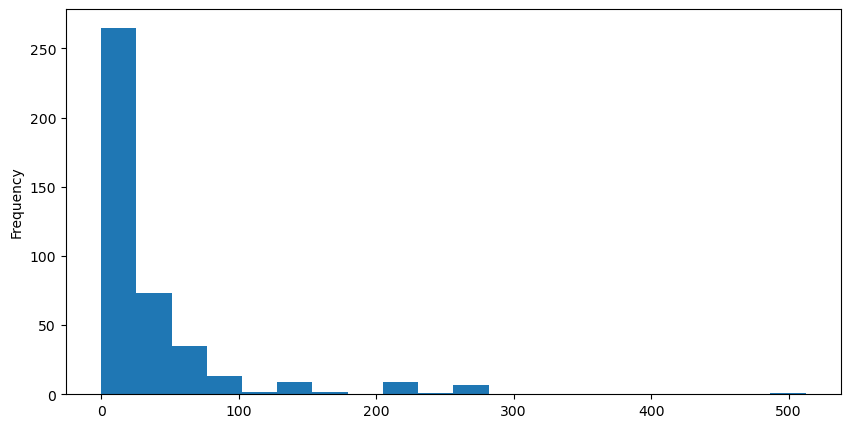

In [114]:
titanic_data["Fare"].plot.hist(bins=20, figsize=(10,5))

In [115]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


<Axes: xlabel='SibSp', ylabel='count'>

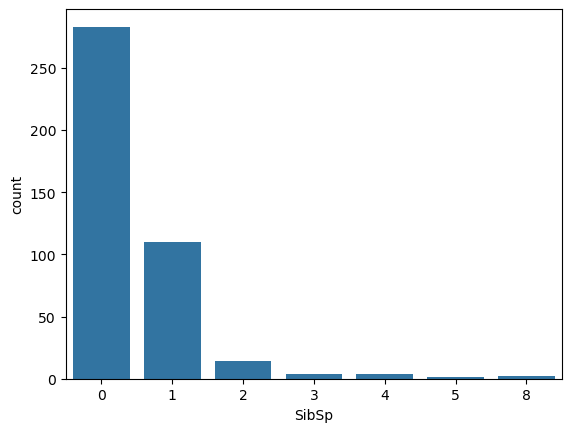

In [116]:
sns.countplot(x="SibSp" , data=titanic_data)

In [117]:
# data cleaning 
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

<Axes: >

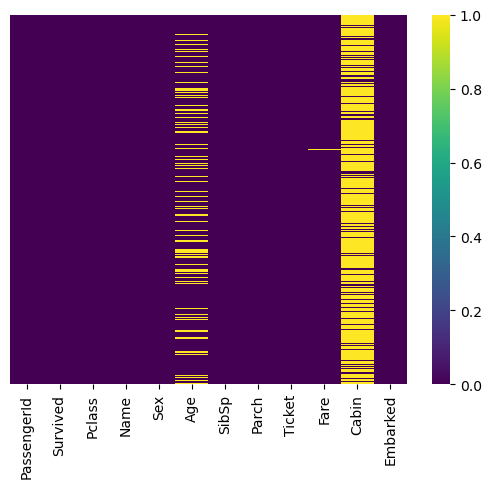

In [118]:
sns.heatmap(titanic_data.isnull() , yticklabels=False , cmap='viridis')

<Axes: xlabel='Pclass', ylabel='Age'>

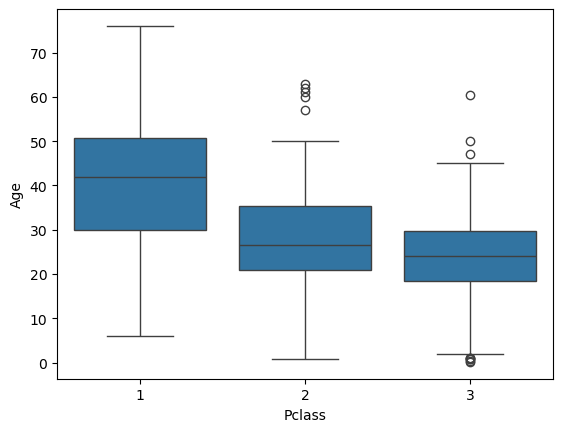

In [119]:
sns.boxplot(x='Pclass' , y='Age' , data=titanic_data)

In [120]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [121]:
titanic_data.drop("Cabin" , axis=1 , inplace=True)

In [122]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


In [123]:
titanic_data.dropna(inplace=True)

<Axes: >

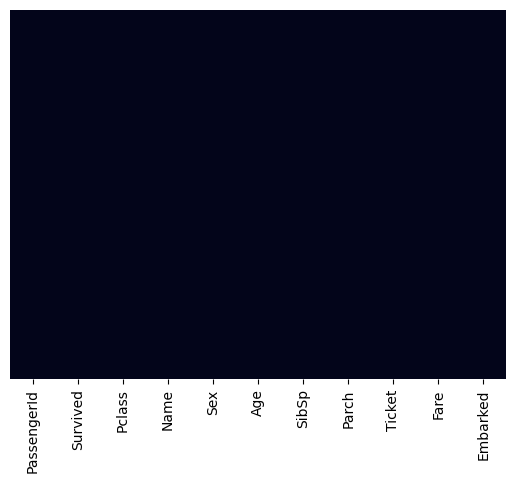

In [124]:
sns.heatmap(titanic_data.isnull() , yticklabels=False , cbar=False)

In [125]:
sex = pd.get_dummies(titanic_data['Sex'], drop_first=True, dtype=int)
sex.head()

,male
0,1
1,0
2,1
3,1
4,0


In [126]:
embark = pd.get_dummies(titanic_data['Embarked'], drop_first=True, dtype=int)
embark.head()

,Q,S
0,1,0
1,0,1
2,1,0
3,0,1
4,0,1


In [127]:
pcl = pd.get_dummies(titanic_data['Pclass'], prefix='Pclass', drop_first=True, dtype=int)
pcl.head()

,Pclass_2,Pclass_3
0,0,1
1,0,1
2,1,0
3,0,1
4,0,1


In [128]:
titanic_data=pd.concat([titanic_data, sex, embark, pcl], axis=1)

In [129]:
titanic_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S,Pclass_2,Pclass_3
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q,1,1,0,0,1
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S,0,0,1,0,1
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q,1,1,0,1,0
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S,1,0,1,0,1
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S,0,0,1,0,1
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,S,1,0,1,0,1
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,Q,0,1,0,0,1
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,S,1,0,1,1,0
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,C,0,0,0,0,1
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,S,1,0,1,0,1


In [130]:
titanic_data.drop(['Sex' , 'Embarked' , 'PassengerId' , 'Name' , 'Ticket'], axis=1, inplace=True)

In [131]:
titanic_data.head(10)

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S,Pclass_2,Pclass_3
0,0,3,34.5,0,0,7.8292,1,1,0,0,1
1,1,3,47.0,1,0,7.0000,0,0,1,0,1
2,0,2,62.0,0,0,9.6875,1,1,0,1,0
3,0,3,27.0,0,0,8.6625,1,0,1,0,1
4,1,3,22.0,1,1,12.2875,0,0,1,0,1
5,0,3,14.0,0,0,9.2250,1,0,1,0,1
6,1,3,30.0,0,0,7.6292,0,1,0,0,1
7,0,2,26.0,1,1,29.0000,1,0,1,1,0
8,1,3,18.0,0,0,7.2292,0,0,0,0,1
9,0,3,21.0,2,0,24.1500,1,0,1,0,1


In [132]:
titanic_data.drop('Pclass' , axis=1 , inplace=True)

In [133]:
titanic_data.head(10)

,Survived,Age,SibSp,Parch,Fare,male,Q,S,Pclass_2,Pclass_3
0,0,34.5,0,0,7.8292,1,1,0,0,1
1,1,47.0,1,0,7.0000,0,0,1,0,1
2,0,62.0,0,0,9.6875,1,1,0,1,0
3,0,27.0,0,0,8.6625,1,0,1,0,1
4,1,22.0,1,1,12.2875,0,0,1,0,1
5,0,14.0,0,0,9.2250,1,0,1,0,1
6,1,30.0,0,0,7.6292,0,1,0,0,1
7,0,26.0,1,1,29.0000,1,0,1,1,0
8,1,18.0,0,0,7.2292,0,0,0,0,1
9,0,21.0,2,0,24.1500,1,0,1,0,1


In [134]:
titanic_data = titanic_data.loc[:, ~titanic_data.columns.duplicated()]
titanic_data.columns[titanic_data.columns.duplicated()]

Index([], dtype='object')

In [135]:
# Training data
X= titanic_data.drop("Survived" , axis=1)
y= titanic_data["Survived"]

In [136]:
from sklearn.model_selection import train_test_split

In [137]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [138]:
from sklearn.linear_model import LogisticRegression

In [139]:
logmodel = LogisticRegression()

In [142]:
logmodel.fit(X_train , y_train)

/home/simocompsci/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [143]:
predictions = logmodel.predict(X_test)

In [144]:
from sklearn.metrics import classification_report
classification_report(y_test , predictions)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        66\n           1       1.00      1.00      1.00        34\n\n    accuracy                           1.00       100\n   macro avg       1.00      1.00      1.00       100\nweighted avg       1.00      1.00      1.00       100\n'

In [145]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test , predictions)

array([[66,  0],
       [ 0, 34]])

In [146]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , predictions)

1.0